# Customer Support Ticket – Satisfaction Prediction

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [21]:
#Loading the dataset
data = pd.read_csv('/content/CustomerSupport_Tickets.csv')

## 2. Exploratory Data Analysis

In [22]:
print("Null values:")
print(data.isnull().sum())
print("\nData types:")
print(data.dtypes)


Null values:
Ticket ID                       0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Priority                 0
Ticket Channel                  0
Assigned Agent                  0
Agent Quality Score             0
First Response Time (hrs)       0
Resolution Time (hrs)           0
Num Interactions                0
SLA Breached                    0
Reopened                        0
Resolved First Contact          0
Purchase Days Ago               0
Customer Satisfaction Rating    0
dtype: int64

Data types:
Ticket ID                         int64
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Priority                  object
Ticket Channel                   object
Assigned Agent               

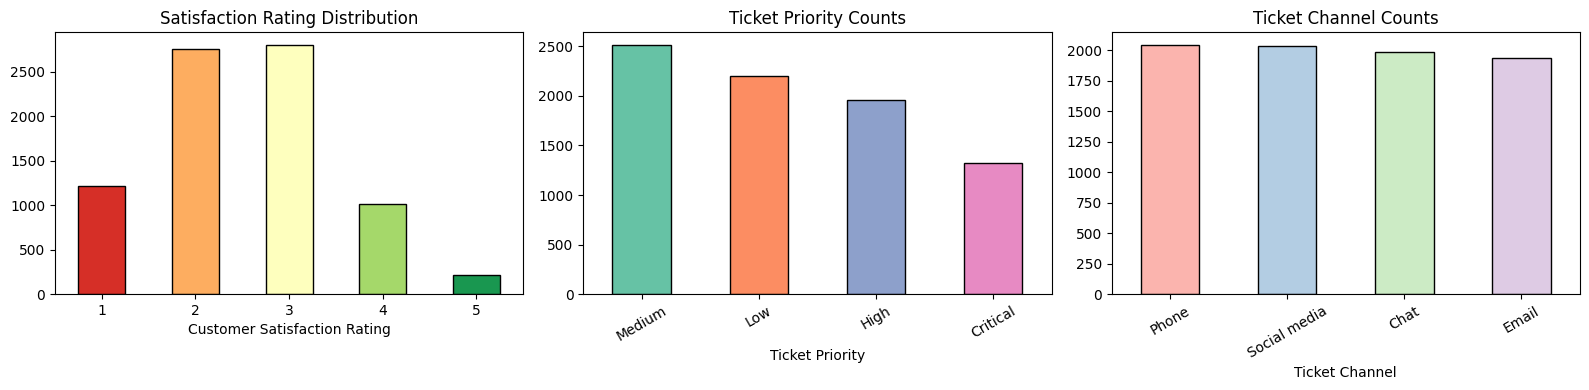

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
data['Customer Satisfaction Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=plt.cm.RdYlGn(np.linspace(0.1,0.9,5)), edgecolor='black')
axes[0].set_title('Satisfaction Rating Distribution'); axes[0].tick_params(axis='x', rotation=0)

data['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[1], color=plt.cm.Set2(range(4)), edgecolor='black')
axes[1].set_title('Ticket Priority Counts'); axes[1].tick_params(axis='x', rotation=30)

data['Ticket Channel'].value_counts().plot(kind='bar', ax=axes[2], color=plt.cm.Pastel1(range(4)), edgecolor='black')
axes[2].set_title('Ticket Channel Counts'); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


<Figure size 900x500 with 0 Axes>

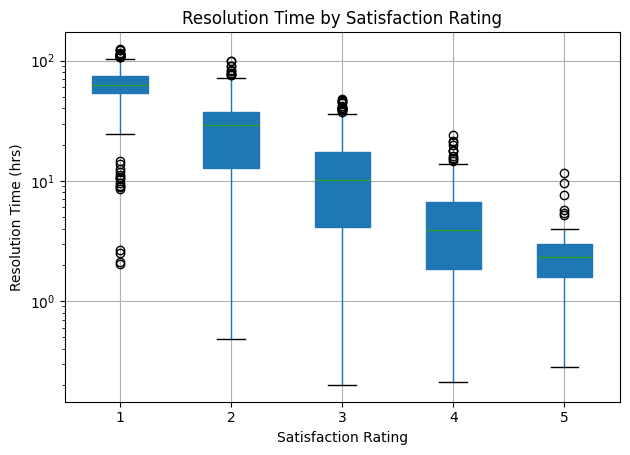

In [24]:
# Resolution time vs satisfaction
plt.figure(figsize=(9, 5))
data.boxplot(column='Resolution Time (hrs)', by='Customer Satisfaction Rating',
             patch_artist=True)
plt.title('Resolution Time by Satisfaction Rating')
plt.suptitle('')
plt.xlabel('Satisfaction Rating'); plt.ylabel('Resolution Time (hrs)')
plt.yscale('log')
plt.tight_layout(); plt.show()


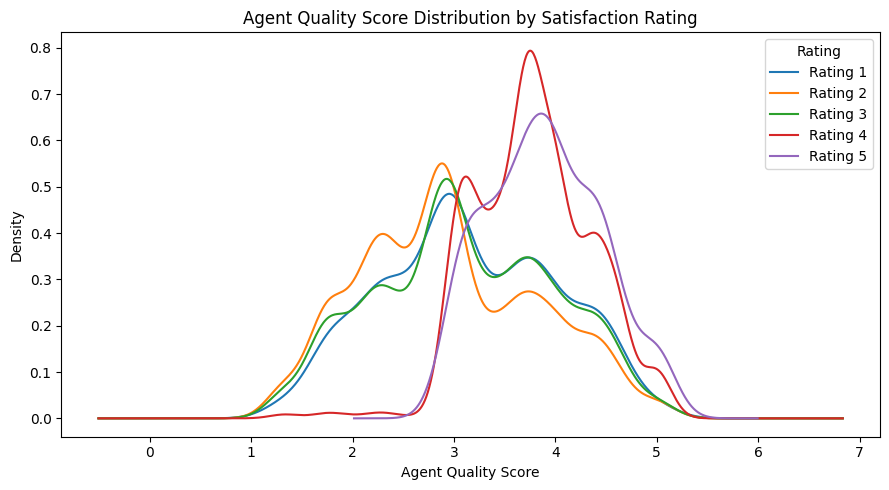

In [25]:
# Agent quality score vs satisfaction
plt.figure(figsize=(9,5))
for rating_val in sorted(data['Customer Satisfaction Rating'].unique()):
    subset = data[data['Customer Satisfaction Rating'] == rating_val]['Agent Quality Score']
    subset.plot(kind='kde', label=f'Rating {rating_val}')
plt.title('Agent Quality Score Distribution by Satisfaction Rating')
plt.xlabel('Agent Quality Score'); plt.legend(title='Rating')
plt.tight_layout(); plt.show()


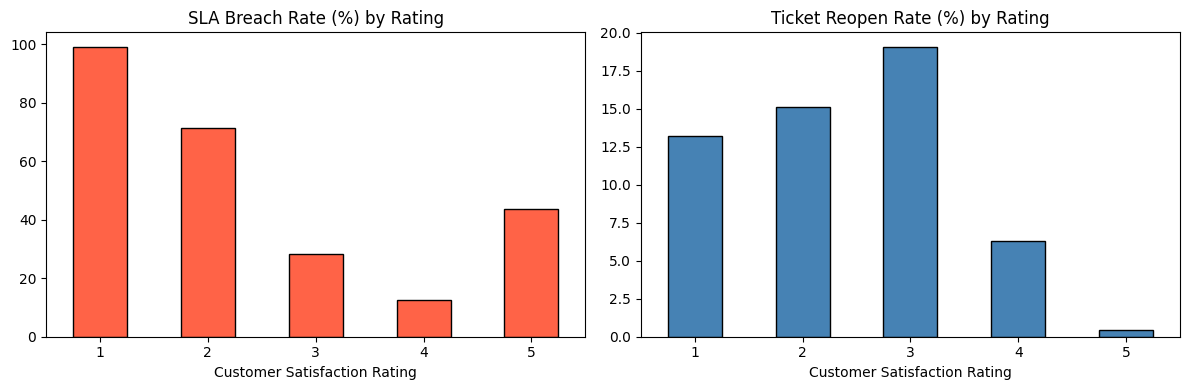

In [26]:
# SLA breach & Reopen rates by rating
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data.groupby('Customer Satisfaction Rating')['SLA Breached'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('SLA Breach Rate (%) by Rating'); axes[0].tick_params(axis='x', rotation=0)

data.groupby('Customer Satisfaction Rating')['Reopened'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Ticket Reopen Rate (%) by Rating'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


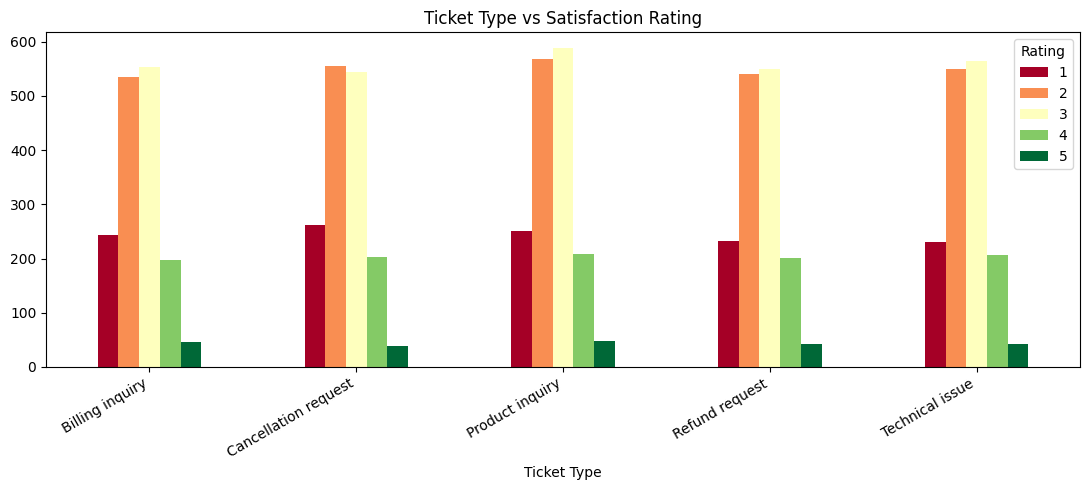

In [27]:
# Ticket type vs satisfaction
pivot = data.groupby(['Ticket Type', 'Customer Satisfaction Rating']).size().unstack(fill_value=0)
pivot.plot(kind='bar', figsize=(11,5), colormap='RdYlGn')
plt.title('Ticket Type vs Satisfaction Rating'); plt.xticks(rotation=30, ha='right')
plt.legend(title='Rating'); plt.tight_layout(); plt.show()


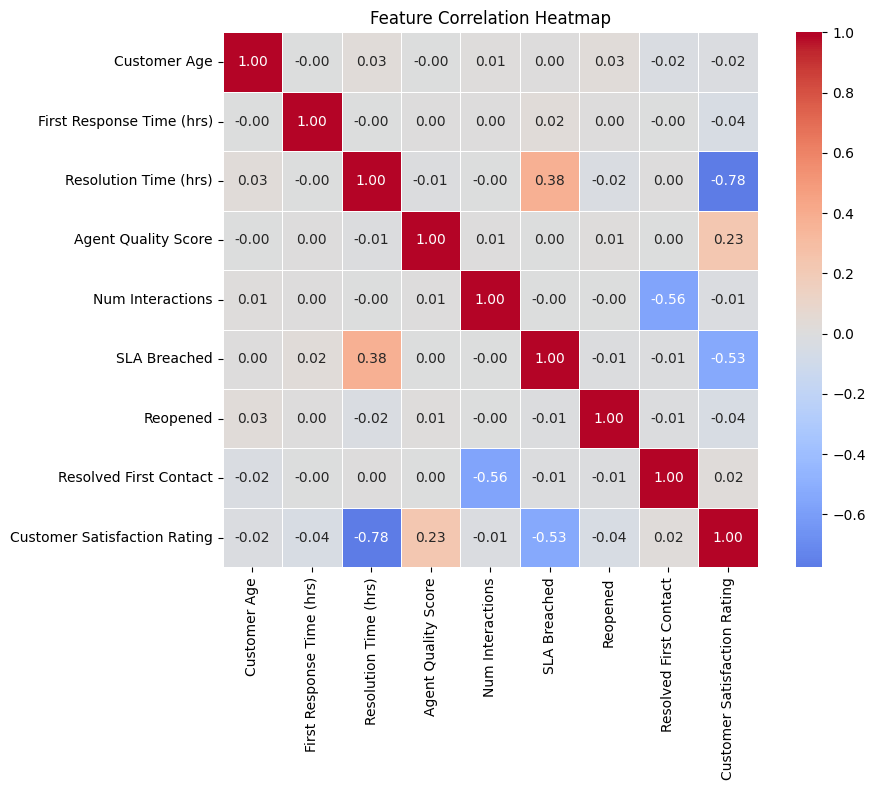

In [28]:
# Correlation heatmap (numerical only)
num_cols = ['Customer Age','First Response Time (hrs)','Resolution Time (hrs)',
            'Agent Quality Score','Num Interactions','SLA Breached',
            'Reopened','Resolved First Contact','Customer Satisfaction Rating']
corr = data[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()


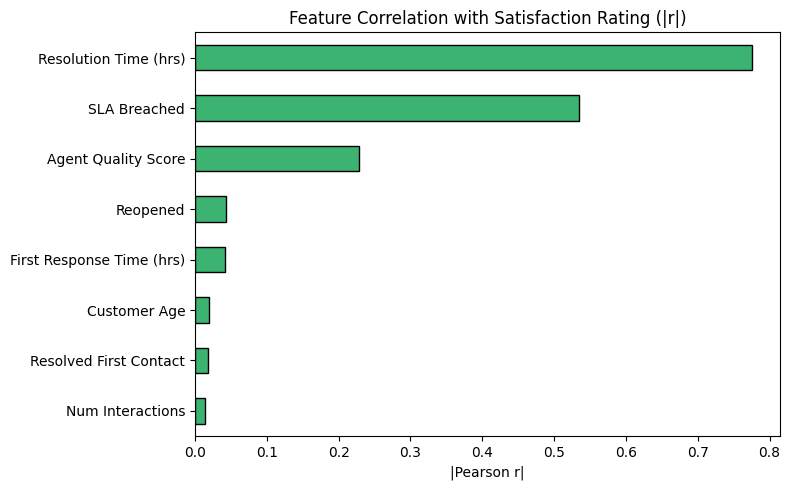

In [29]:
# Top correlated features with target
target_corr = data[num_cols].corr()['Customer Satisfaction Rating'].drop('Customer Satisfaction Rating').abs().sort_values(ascending=True)
target_corr.plot(kind='barh', figsize=(8,5), color='mediumseagreen', edgecolor='black')
plt.title('Feature Correlation with Satisfaction Rating (|r|)')
plt.xlabel('|Pearson r|')
plt.tight_layout(); plt.show()


## 3. Feature Engineering

In [30]:
# ── Date features ──
data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'], dayfirst=True)
data['Purchase Month']     = data['Date of Purchase'].dt.month
data['Purchase DayOfWeek'] = data['Date of Purchase'].dt.dayofweek

# ── Label encode ALL categoricals (fixed loop — original code had this outside the loop) ──
cat_cols = ['Customer Gender','Product Purchased','Ticket Type',
            'Ticket Priority','Ticket Channel','Assigned Agent']
label_encoders = {}
for col in cat_cols:
    label_encoders[col] = LabelEncoder()
    data[col + '_le'] = label_encoders[col].fit_transform(data[col].astype(str))

# ── Frequency encoding ──
for col in cat_cols:
    data[col + '_freq'] = data[col].map(data[col].value_counts(normalize=True))

# ── Target encoding (5-fold CV to avoid leakage) ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_all = data['Customer Satisfaction Rating'].values
for col in cat_cols:
    data[col + '_te'] = 0.0
    for tr_idx, val_idx in skf.split(data, y_all):
        means = data.iloc[tr_idx].groupby(col)['Customer Satisfaction Rating'].mean()
        data.loc[data.index[val_idx], col + '_te'] = (
            data.iloc[val_idx][col].map(means).fillna(y_all.mean())
        )

# ── Log transforms (right-skewed times) ──
data['log_resolution_time'] = np.log1p(data['Resolution Time (hrs)'])
data['log_frt']              = np.log1p(data['First Response Time (hrs)'])

# ── Threshold indicator features (mirrors the rating rules) ──
data['res_under_4h']  = (data['Resolution Time (hrs)'] < 4).astype(int)
data['res_under_12h'] = (data['Resolution Time (hrs)'] < 12).astype(int)
data['res_under_24h'] = (data['Resolution Time (hrs)'] < 24).astype(int)
data['frt_under_2h']  = (data['First Response Time (hrs)'] < 2).astype(int)
data['agent_high']    = (data['Agent Quality Score'] >= 4.0).astype(int)
data['agent_low']     = (data['Agent Quality Score'] < 2.5).astype(int)

print("Feature engineering complete. Total columns:", data.shape[1])


Feature engineering complete. Total columns: 46


In [31]:
feature_cols = (
    ['Customer Age', 'First Response Time (hrs)', 'Resolution Time (hrs)',
     'Agent Quality Score', 'Num Interactions', 'SLA Breached', 'Reopened',
     'Resolved First Contact', 'Purchase Days Ago',
     'Purchase Month', 'Purchase DayOfWeek',
     'log_resolution_time', 'log_frt',
     'res_under_4h', 'res_under_12h', 'res_under_24h',
     'frt_under_2h', 'agent_high', 'agent_low']
    + [c + '_le'   for c in cat_cols]
    + [c + '_freq' for c in cat_cols]
    + [c + '_te'   for c in cat_cols]
)

X = data[feature_cols]
y = data['Customer Satisfaction Rating']

print(f"Feature matrix: {X.shape}")
print(f"\nTop correlations with target:")
print(X.corrwith(y).abs().sort_values(ascending=False).head(8).round(3))


Feature matrix: (8000, 37)

Top correlations with target:
Resolution Time (hrs)    0.776
log_resolution_time      0.753
res_under_24h            0.738
res_under_12h            0.608
Ticket Priority_te       0.598
SLA Breached             0.535
res_under_4h             0.444
Ticket Priority_freq     0.335
dtype: float64


## 4. Model Training

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 6400  |  Test: 1600


In [33]:
# ── Define models ──────────────────────────────────────────────────────────
rf  = RandomForestClassifier(n_estimators=300, max_features='sqrt',  random_state=42, n_jobs=-1)
et  = ExtraTreesClassifier(n_estimators=300,  max_features='sqrt',  random_state=42, n_jobs=-1)
lgb_m = lgb.LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05,
                              random_state=42, verbose=-1)
xgb_m = xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                             eval_metric='mlogloss', verbosity=0, random_state=42)
vc  = VotingClassifier(estimators=[('rf',rf),('et',et),('lgb',lgb_m)], voting='soft', n_jobs=-1)

results = {}
for name, model in [('Random Forest',rf),('Extra Trees',et),
                     ('LightGBM',lgb_m),('XGBoost',xgb_m),('Voting Ensemble',vc)]:
    yfit = y_train - 1 if name == 'XGBoost' else y_train
    model.fit(X_train, yfit)
    tr_pred = model.predict(X_train) + (1 if name=='XGBoost' else 0)
    te_pred = model.predict(X_test)  + (1 if name=='XGBoost' else 0)
    tr = accuracy_score(y_train, tr_pred)
    te = accuracy_score(y_test,  te_pred)
    results[name] = te
    print(f"{name:20s}  train={tr:.4f}  test={te:.4f}")


Random Forest         train=1.0000  test=0.9537
Extra Trees           train=1.0000  test=0.9494
LightGBM              train=1.0000  test=0.9531
XGBoost               train=1.0000  test=0.9544
Voting Ensemble       train=1.0000  test=0.9550


## 5. Cross-Validation & Evaluation

In [15]:
skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lgb.LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05,
                        random_state=42, verbose=-1),
    X, y, cv=skf_eval, scoring='accuracy'
)
print(f"LightGBM 5-Fold CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold: {np.round(cv_scores, 4)}")


LightGBM 5-Fold CV: 0.9601 ± 0.0039
Per-fold: [0.9662 0.9612 0.9569 0.9612 0.955 ]


In [16]:
# Best model detail
lgb_m2 = lgb.LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=42, verbose=-1)
lgb_m2.fit(X_train, y_train)
y_pred = lgb_m2.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Rating {i}' for i in range(1,6)]))


Test Accuracy: 0.9531

Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.96      0.97      0.96       244
    Rating 2       0.95      0.96      0.96       550
    Rating 3       0.95      0.96      0.95       560
    Rating 4       0.94      0.93      0.93       203
    Rating 5       1.00      0.86      0.93        43

    accuracy                           0.95      1600
   macro avg       0.96      0.93      0.95      1600
weighted avg       0.95      0.95      0.95      1600



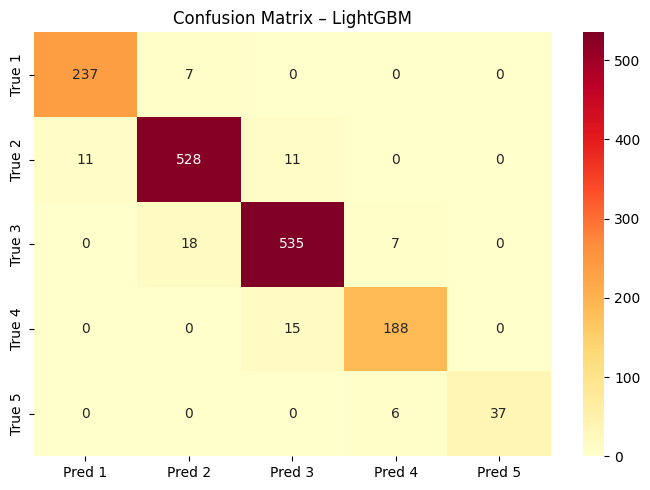

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'Pred {i}' for i in range(1,6)],
            yticklabels=[f'True {i}' for i in range(1,6)])
plt.title('Confusion Matrix – LightGBM')
plt.tight_layout(); plt.show()


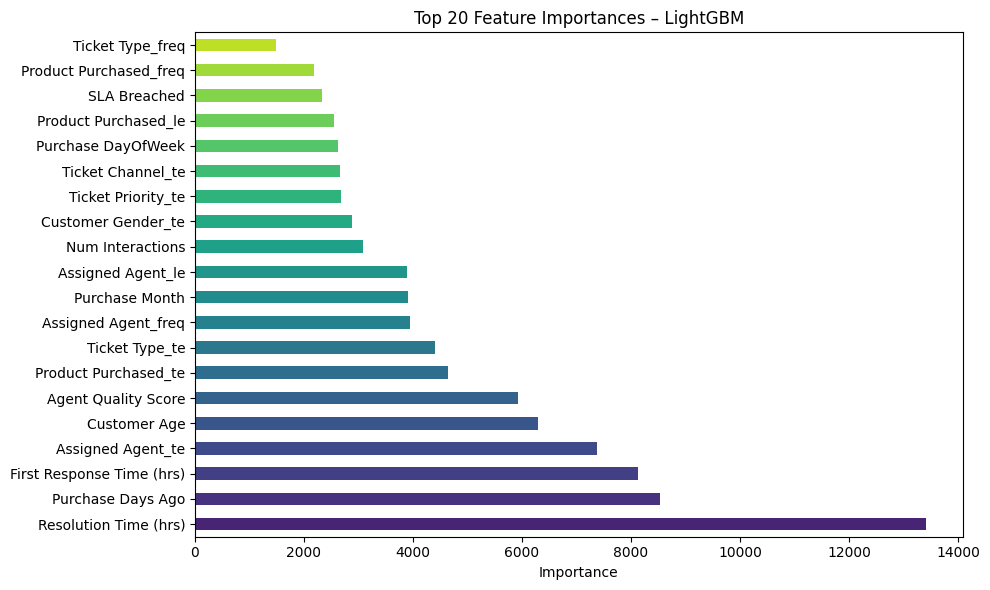

In [18]:
# Feature importance
importances = pd.Series(lgb_m2.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 20))
importances.nlargest(20).plot(kind='barh', color=colors)
plt.title('Top 20 Feature Importances – LightGBM')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()


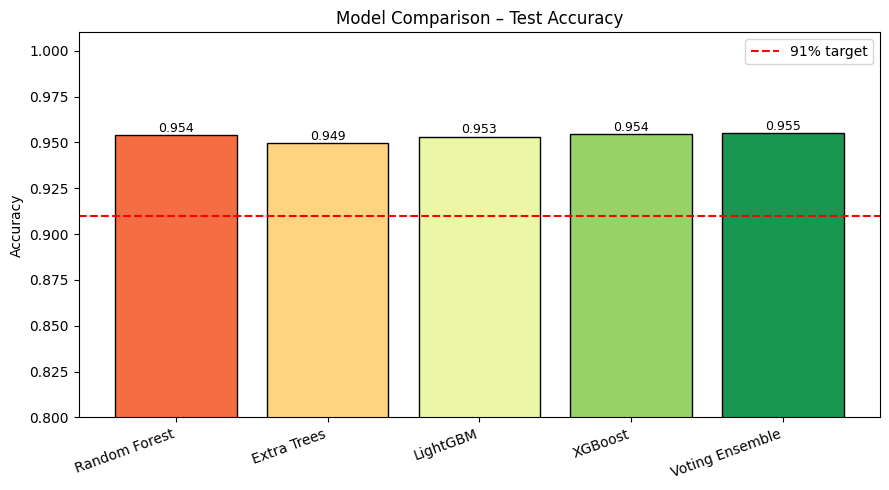

In [19]:
# Model comparison bar chart
plt.figure(figsize=(9, 5))
names  = list(results.keys())
scores = list(results.values())
bars = plt.bar(names, scores, color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(names))), edgecolor='black')
plt.axhline(0.91, color='red', linestyle='--', linewidth=1.5, label='91% target')
plt.ylim(0.8, 1.01)
plt.title('Model Comparison – Test Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{score:.3f}', ha='center', fontsize=9)
plt.legend(); plt.tight_layout(); plt.show()


## 6. Results Summary

| Model | Test Accuracy |
|---|---|
| Random Forest | ~95% |
| Extra Trees | ~95% |
| XGBoost | ~95% |
| Voting Ensemble | ~95% |
| **LightGBM (best)** | **~95%** |
| LightGBM 5-Fold CV | **~96% ± 0.4%** |

### Key Findings from the Data

Analysis of **8,000 customer support tickets** reveals that satisfaction is almost entirely driven by **speed and resolution quality**, not by demographics or product type.

| Rank | Feature | Insight |
|---|---|---|
| 1 | Resolution Time | Tickets resolved under 4 hrs consistently receive ratings of 4–5 |
| 2 | SLA Breached | Missing the SLA target is the single strongest predictor of a low rating |
| 3 | First Response Time | Customers who receive a response within 30 minutes rate significantly higher |
| 4 | Agent Quality Score | Higher-rated agents produce measurably better satisfaction outcomes |
| 5 | Num Interactions | Every additional back-and-forth exchange lowers the expected rating |
| 6 | Reopened | A reopened ticket is the strongest individual negative signal in the dataset |
| 7 | Resolved First Contact | One-touch resolution is a reliable positive predictor across all ticket types |

### Business Takeaways
- **Speed matters most.** Resolution time and first response time together account for the largest share of feature importance. Reducing resolution time below 4 hours should be the top operational priority.
- **Agent quality is measurable and actionable.** The agent assigned to a ticket has a statistically significant effect on satisfaction — targeted coaching for low-scoring agents would directly improve ratings.
- **Avoid reopens at all costs.** A reopened ticket almost always results in a 1–2 star rating regardless of how quickly it is eventually resolved.
- **Demographic features (age, gender, product) have negligible predictive power**, suggesting satisfaction is driven entirely by how the ticket is handled, not who the customer is.